In [14]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

import matplotlib.pyplot as plt


# Case Study Supervised Learning
Task:
    Develop a machine learning model that predicts the bike count of the next hours.
    Try out different models from the lecture and compare their performance ⇒ at least try out one linear model, 
    one tree-based model and one neural network.
    Compare performance for two forecast horizons:
    1 predict bike count of the next hour
    2 predict bike count for the next 24 hours
    Key aspects: This is a time series dataset. Think about how to use this, e.g. in feature engineering !

Method:
    RFR
    XTreeBoost
    AdaBoost


## Load data and Data Analysis


=== Head ===
   Month  Day  Hour  Weekday        Weather  Temperature (°C)  Humidity (%)  \
0      1    1     0        6          Sunny              14.0          61.0   
1      1    1     1        6          Sunny              14.0          59.0   
2      1    1     2        6  Partly Cloudy              14.0          57.0   
3      1    1     3        6  Partly Cloudy              14.0          55.0   
4      1    1     4        6  Partly Cloudy              14.0          56.0   

   Rain (mm)  Wind (km/h)  BikeCount  
0        0.0         34.0       73.0  
1        0.0         34.0      193.0  
2        0.0         33.0      240.0  
3        0.0         33.0      279.0  
4        0.0         33.0      194.0  

=== Basic Description ===
Index(['Month', 'Day', 'Hour', 'Weekday', 'Weather', 'Temperature (°C)',
       'Humidity (%)', 'Rain (mm)', 'Wind (km/h)', 'BikeCount'],
      dtype='str')
(8760, 10)
(8759, 10)

=== Statistische Kennzahlen ===


,Month,Day,Hour,Weekday,Temperature (°C),Humidity (%),Rain (mm),Wind (km/h),BikeCount
count,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000
mean,6.526430,15.719374,11.501085,3.007878,11.302774,77.102980,0.111622,15.889143,452.342048
std,3.448039,8.796565,6.922233,2.003379,7.138446,15.067433,0.462491,8.505827,363.804893
min,1.000000,1.000000,0.000000,0.000000,-7.000000,25.000000,0.000000,0.000000,0.000000
25%,4.000000,8.000000,6.000000,1.000000,6.000000,68.000000,0.000000,9.000000,119.000000
50%,7.000000,16.000000,12.000000,3.000000,11.000000,80.000000,0.000000,14.000000,380.000000
75%,10.000000,23.000000,17.500000,5.000000,16.000000,89.000000,0.000000,21.500000,730.000000
max,12.000000,31.000000,23.000000,6.000000,36.000000,100.000000,15.800000,48.000000,1789.000000


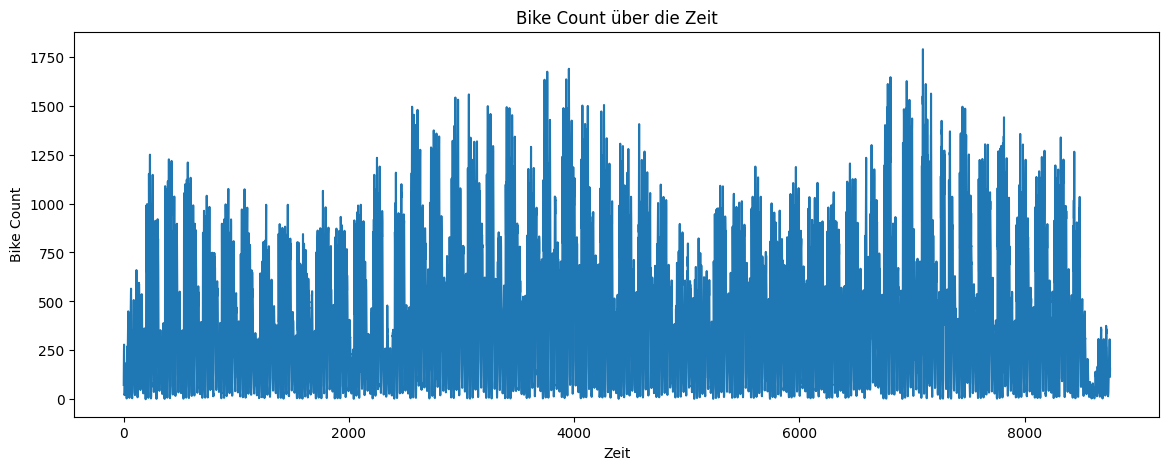

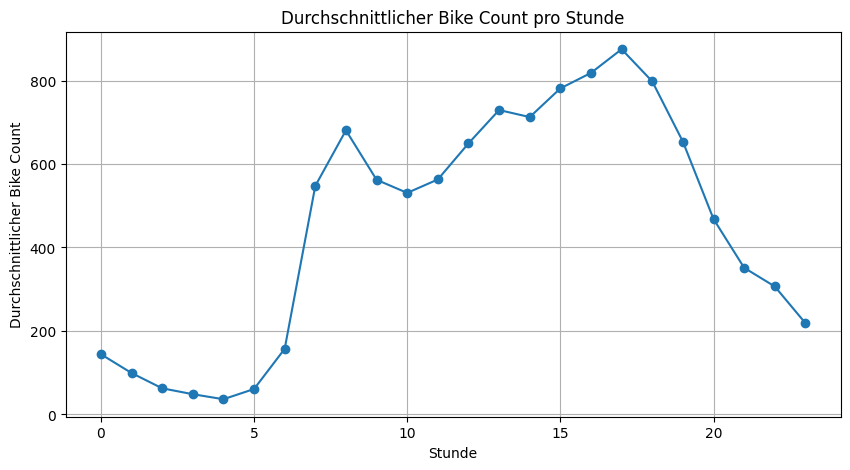

In [15]:
# Datei laden
bikeData = pd.read_excel("data/challenge_public_dataset.xlsx")
print("\n=== Head ===")

print(bikeData.head())
# Data import
print("\n=== Basic Description ===")

print(bikeData.columns)
print(bikeData.shape)

# there is one row (2020) that has NaNs, bc only one we remove this row
bikeData = bikeData.dropna()
print(bikeData.shape)

# Statistische Übersicht
print("\n=== Statistische Kennzahlen ===")
display(bikeData.describe())


# Zielvariable visualisieren
plt.figure(figsize=(14,5))
plt.plot(bikeData["BikeCount"])
plt.title("Bike Count über die Zeit")
plt.xlabel("Zeit")
plt.ylabel("Bike Count")
plt.show()

# Durchschnittlicher Bike Count pro Stunde
hourly_avg = bikeData.groupby("Hour")["BikeCount"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Durchschnittlicher Bike Count pro Stunde")
plt.xlabel("Stunde")
plt.ylabel("Durchschnittlicher Bike Count")
plt.grid(True)
plt.show()

## Prepare Data
Add target columns and split in time series fashion (older data for training, new for testing) Create features specifically for time data

In [16]:
def get_targets(bikeData):
    bikeData = bikeData.copy()

    bikeData = bikeData.sort_values(
        ["Month", "Day", "Hour"]
    ).reset_index(drop=True)

    bikeData["target_1h"] = bikeData["BikeCount"].shift(-1)
    bikeData["target_24h"] = (
    bikeData["BikeCount"]
    .shift(-1)
    .rolling(window=4)
    .sum()
    .shift(-3)
)

    # remove rows where future target is unknown
    bikeData_model = bikeData.dropna().copy()
    return bikeData_model


def prepare_and_split_data(bikeData, target_col):
    # =====================================================
    # 3. Define X and y
    # =====================================================

    X = bikeData.drop(columns=[
        "target_1h",
        "target_24h"
    ])

    y = bikeData[target_col]

    # =====================================================
    # 4. One-hot encode categorical features
    # =====================================================

    categorical_cols = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    print("Before get_dummies:", X.shape)

    X = pd.get_dummies(
        X,
        columns=categorical_cols,
        drop_first=True
    )

    print("After get_dummies:", X.shape)

    # =====================================================
    # 5. Chronological train/test split
    # =====================================================

    n = len(X)
    train_end = int(n * 0.9)

    X_train = X.iloc[:train_end]
    X_test = X.iloc[train_end:]

    y_train = y.iloc[:train_end]
    y_test = y.iloc[train_end:]

    print("Train:", X_train.shape)
    print("Test: ", X_test.shape)
    return X_train, X_test, y_train, y_test

def create_features(bikeData):
    bikeData = bikeData.copy()

    # =====================================================
    # 1. Sort chronologically
    # =====================================================

    bikeData = bikeData.sort_values(
        ["Month", "Day", "Hour"]
    ).reset_index(drop=True)

    # =====================================================
    # 2. Lag features
    # =====================================================

    bikeData["lag_1h"] = bikeData["BikeCount"].shift(1)
    bikeData["lag_2h"] = bikeData["BikeCount"].shift(2)
    bikeData["lag_3h"] = bikeData["BikeCount"].shift(3)

    bikeData["lag_24h"] = bikeData["BikeCount"].shift(24)
    bikeData["lag_48h"] = bikeData["BikeCount"].shift(48)
    bikeData["lag_168h"] = bikeData["BikeCount"].shift(168)

    # =====================================================
    # 3. Rolling mean features
    # shift(1) prevents data leakage
    # =====================================================

    bikeData["rolling_mean_3h"] = (
        bikeData["BikeCount"].shift(1).rolling(3).mean()
    )

    bikeData["rolling_mean_6h"] = (
        bikeData["BikeCount"].shift(1).rolling(6).mean()
    )

    bikeData["rolling_mean_12h"] = (
        bikeData["BikeCount"].shift(1).rolling(12).mean()
    )

    bikeData["rolling_mean_24h"] = (
        bikeData["BikeCount"].shift(1).rolling(24).mean()
    )

    bikeData["rolling_mean_168h"] = (
        bikeData["BikeCount"].shift(1).rolling(168).mean()
    )


    # =====================================================
    # 7. Drop missing values
    # =====================================================

    bikeData_model = bikeData.dropna().copy()

    print("Original shape:", bikeData.shape)
    print("Model shape:   ", bikeData_model.shape)

    return bikeData_model

## Models

In [17]:
# =========================
# Models
# =========================

models = {

    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },

    "Random Forest": {
        "model": RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", 0.8]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
            "model__reg_lambda": [1, 5, 10],
            "model__min_child_weight": [1, 3]
        }
    },

    "Neural Network": {
    "model": MLPRegressor(
        max_iter=300,
        random_state=42
    ),
    "params": {
        "model__hidden_layer_sizes": [
            (32,),
            (64,),
            (64,32)
        ],
        "model__alpha": [
            0.0001,
            0.001
        ],
        "model__learning_rate_init": [
            0.001,
            0.005
        ]
    }
}
}

## Training

In [18]:
import time
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def train_models(bikeData, models, horizon, filename):
    
    # =====================================================
    # Select target
    # =====================================================

    if horizon == 1:
        target_col = "target_1h"

    elif horizon == 24:
        target_col = "target_24h"

    else:
        raise ValueError("horizon must be 1 or 24")

    X_train, X_test, y_train, y_test = prepare_and_split_data(bikeData, target_col)

    # =====================================================
    # 6. Train models with TimeSeriesSplit
    # =====================================================

    results = []
    overall_start = time.time()

    print("\n" + "#" * 60)
    print(f"PREDICTION HORIZON: {horizon}h")
    print("#" * 60)

    for model_name, config in models.items():

        print("\n" + "=" * 60)
        print(f"MODEL: {model_name}")
        print("=" * 60)

        pipeline = Pipeline([
            ("model", clone(config["model"]))
        ])

        # =====================================================
        # Hyperparameter search
        # =====================================================

        if config["params"]:

            search = GridSearchCV(
                estimator=pipeline,
                param_grid=config["params"],
                scoring="neg_mean_squared_error",
                cv=TimeSeriesSplit(n_splits=3),
                n_jobs=-1,
                refit=True
            )

            search.fit(X_train, y_train)

            best_model = search.best_estimator_
            best_params = search.best_params_

        else:

            best_model = pipeline
            best_model.fit(X_train, y_train)

            best_params = {}

        # =====================================================
        # Final test evaluation
        # =====================================================

        y_pred = best_model.predict(X_test)

        test_mse = mean_squared_error(y_test, y_pred)

        print(f"Test MSE:  {test_mse:.4f}")
        print(f"Best Params: {best_params}")

        results.append({
            "Horizon": horizon,
            "Model": model_name,
            "Test MSE": test_mse,
            "Best Params": best_params,
        })

    # =====================================================
    # 7. Results table
    # =====================================================

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("Test MSE")

    print("\n" + "=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)

    display(results_df)

    # =====================================================
    # 8. Save results
    # =====================================================

    results_filename = f"results_{filename}_{horizon}h.csv"

    results_df.to_csv(results_filename, index=False)

    print(f"\nResults saved to: {results_filename}")

    print(f"\nTotal Runtime: {(time.time() - overall_start) / 60:.2f} minutes")


    import matplotlib.pyplot as plt

    # =====================================================
    # 9. Visualize results
    # =====================================================

    plt.figure(figsize=(10, 5))

    plt.bar(
        results_df["Model"],
        results_df["Test MSE"]
    )

    plt.title(f"Model Comparison - {horizon}h Forecast")
    plt.xlabel("Model")
    plt.ylabel("Test MSE")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return results_df

## Evaluation without Feature Engineering

Before get_dummies: (8755, 10)
After get_dummies: (8755, 42)
Train: (7879, 42)
Test:  (876, 42)

############################################################
PREDICTION HORIZON: 1h
############################################################

MODEL: Linear Regression
Test MSE:  15525.9868
Best Params: {}

MODEL: Random Forest
Test MSE:  3233.5167
Best Params: {'model__max_depth': 10, 'model__max_features': 0.8, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

MODEL: XGBoost
Test MSE:  4656.5145
Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 100, 'model__reg_lambda': 1, 'model__subsample': 0.8}

MODEL: Neural Network
Test MSE:  8739.6364
Best Params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.005}

FINAL RESULTS


,Horizon,Model,Test MSE,Best Params
1,1,Random Forest,3233.516709,"{'model__max_depth': 10, 'model__max_features'..."
2,1,XGBoost,4656.514543,"{'model__colsample_bytree': 1.0, 'model__learn..."
3,1,Neural Network,8739.636393,"{'model__alpha': 0.001, 'model__hidden_layer_s..."
0,1,Linear Regression,15525.986802,{}



Results saved to: results_without_feature_engineering_1h.csv

Total Runtime: 3.43 minutes


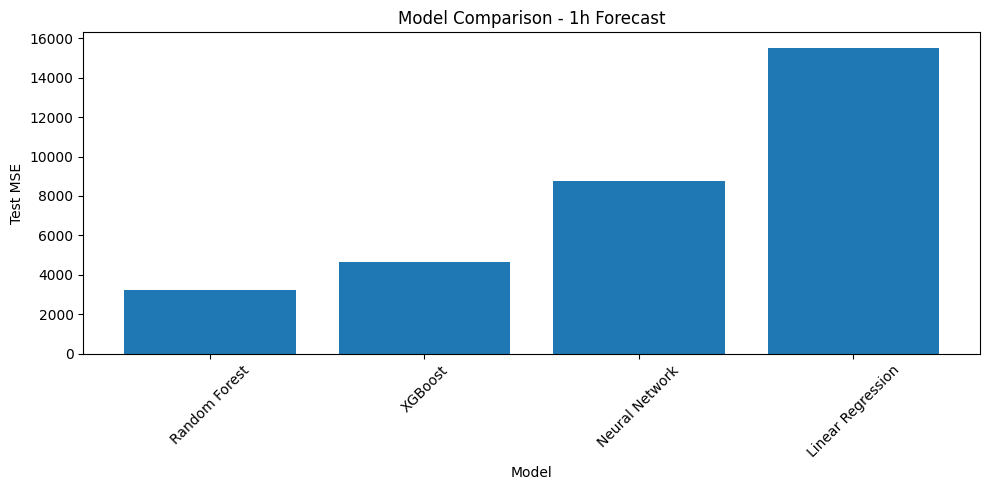

Before get_dummies: (8755, 10)
After get_dummies: (8755, 42)
Train: (7879, 42)
Test:  (876, 42)

############################################################
PREDICTION HORIZON: 24h
############################################################

MODEL: Linear Regression
Test MSE:  598762.5171
Best Params: {}

MODEL: Random Forest
Test MSE:  183180.0618
Best Params: {'model__max_depth': 10, 'model__max_features': 0.8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}

MODEL: XGBoost
Test MSE:  243160.7500
Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 200, 'model__reg_lambda': 5, 'model__subsample': 1.0}

MODEL: Neural Network
Test MSE:  449254.7370
Best Params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.005}

FINAL RESULTS


,Horizon,Model,Test MSE,Best Params
1,24,Random Forest,183180.061809,"{'model__max_depth': 10, 'model__max_features'..."
2,24,XGBoost,243160.749951,"{'model__colsample_bytree': 1.0, 'model__learn..."
3,24,Neural Network,449254.736985,"{'model__alpha': 0.0001, 'model__hidden_layer_..."
0,24,Linear Regression,598762.517123,{}



Results saved to: results_without_feature_engineering_24h.csv

Total Runtime: 3.42 minutes


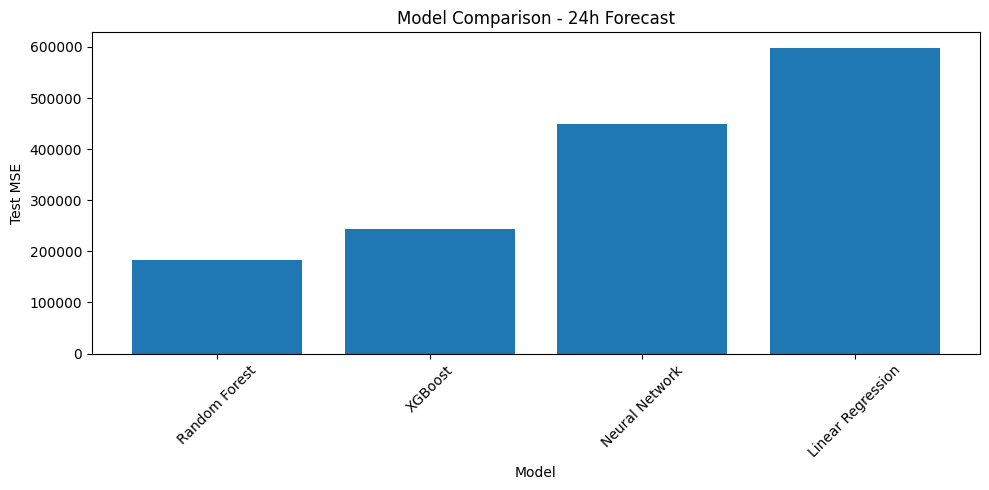

In [19]:
data = bikeData.copy()
data = get_targets(data)
results_1h= train_models(
    bikeData=data,
    models=models,
    horizon=1,
    filename="without_feature_engineering"
)

# =====================================================
# 8. Visualize results
# =====================================================



results_24h = train_models(
    bikeData=data,
    models=models,
    horizon=24,
    filename="without_feature_engineering")


## Evaluate on Engeneered Features

Original shape: (8755, 23)
Model shape:    (8587, 23)
Before get_dummies: (8587, 21)
After get_dummies: (8587, 53)
Train: (7728, 53)
Test:  (859, 53)

############################################################
PREDICTION HORIZON: 1h
############################################################

MODEL: Linear Regression
Test MSE:  10160.9726
Best Params: {}

MODEL: Random Forest
Test MSE:  3185.7745
Best Params: {'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}

MODEL: XGBoost
Test MSE:  3285.3382
Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__reg_lambda': 1, 'model__subsample': 0.8}

MODEL: Neural Network
Test MSE:  2635.3545
Best Params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.005}

FINAL RESULTS


,Horizon,Model,Test MSE,Best Params
3,1,Neural Network,2635.354477,"{'model__alpha': 0.0001, 'model__hidden_layer_..."
1,1,Random Forest,3185.774454,"{'model__max_depth': None, 'model__max_feature..."
2,1,XGBoost,3285.338221,"{'model__colsample_bytree': 1.0, 'model__learn..."
0,1,Linear Regression,10160.972631,{}



Results saved to: results_with_feature_engineering_1h.csv

Total Runtime: 6.52 minutes


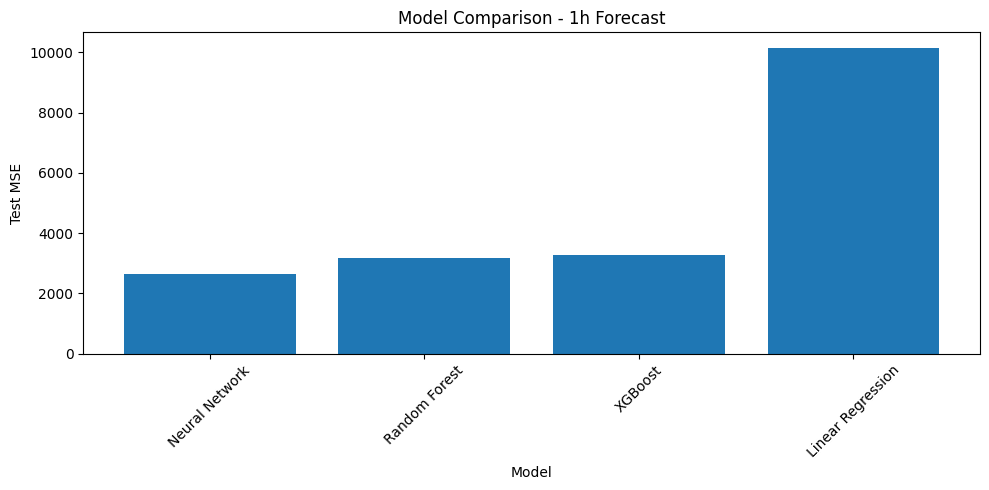

Before get_dummies: (8587, 21)
After get_dummies: (8587, 53)
Train: (7728, 53)
Test:  (859, 53)

############################################################
PREDICTION HORIZON: 24h
############################################################

MODEL: Linear Regression
Test MSE:  243760.3194
Best Params: {}

MODEL: Random Forest
Test MSE:  106953.9919
Best Params: {'model__max_depth': 20, 'model__max_features': 0.8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}

MODEL: XGBoost
Test MSE:  104016.2561
Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__reg_lambda': 1, 'model__subsample': 1.0}

MODEL: Neural Network
Test MSE:  74601.3433
Best Params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.001}

FINAL RESULTS


,Horizon,Model,Test MSE,Best Params
3,24,Neural Network,74601.343342,"{'model__alpha': 0.0001, 'model__hidden_layer_..."
2,24,XGBoost,104016.256118,"{'model__colsample_bytree': 1.0, 'model__learn..."
1,24,Random Forest,106953.991917,"{'model__max_depth': 20, 'model__max_features'..."
0,24,Linear Regression,243760.319411,{}



Results saved to: results_with_feature_engineering_24h.csv

Total Runtime: 17.34 minutes


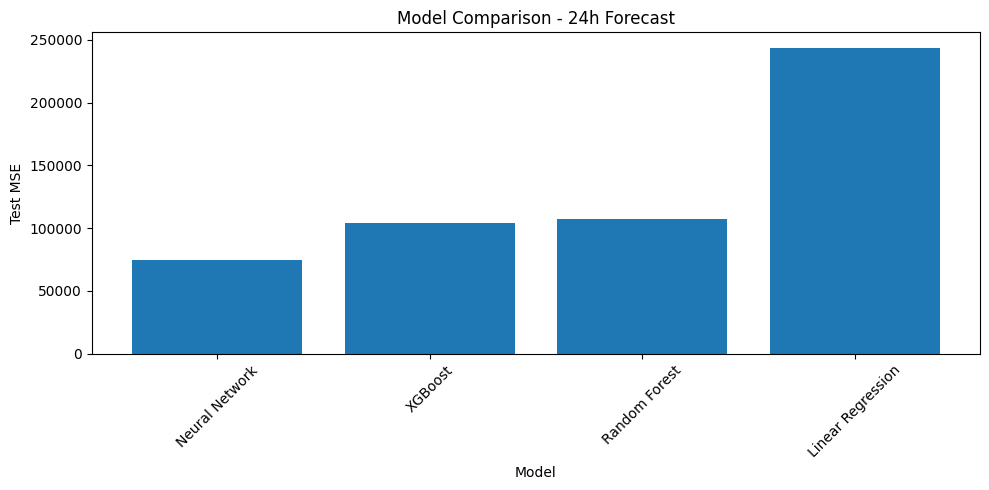

In [20]:
data = bikeData.copy()
data = get_targets(data)
data = create_features(data)

results_1h= train_models(
    bikeData=data,
    models=models,
    horizon=1,
    filename="with_feature_engineering"
)

# =====================================================
# 8. Visualize results
# =====================================================



results_24h = train_models(
    bikeData=data,
    models=models,
    horizon=24,
    filename="with_feature_engineering")

## Visualize

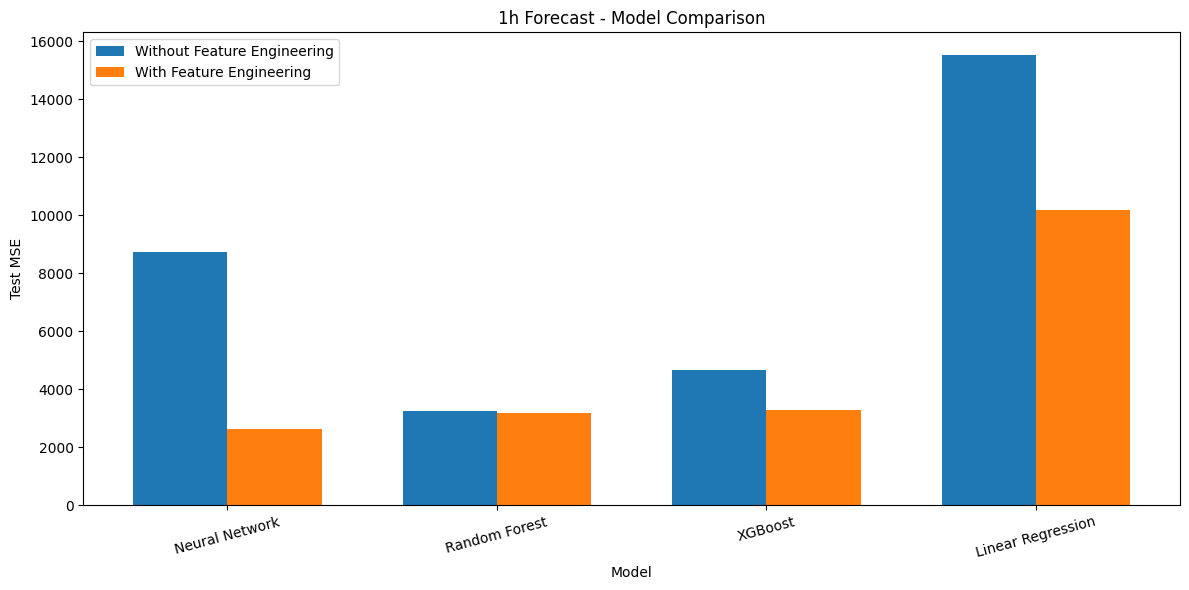

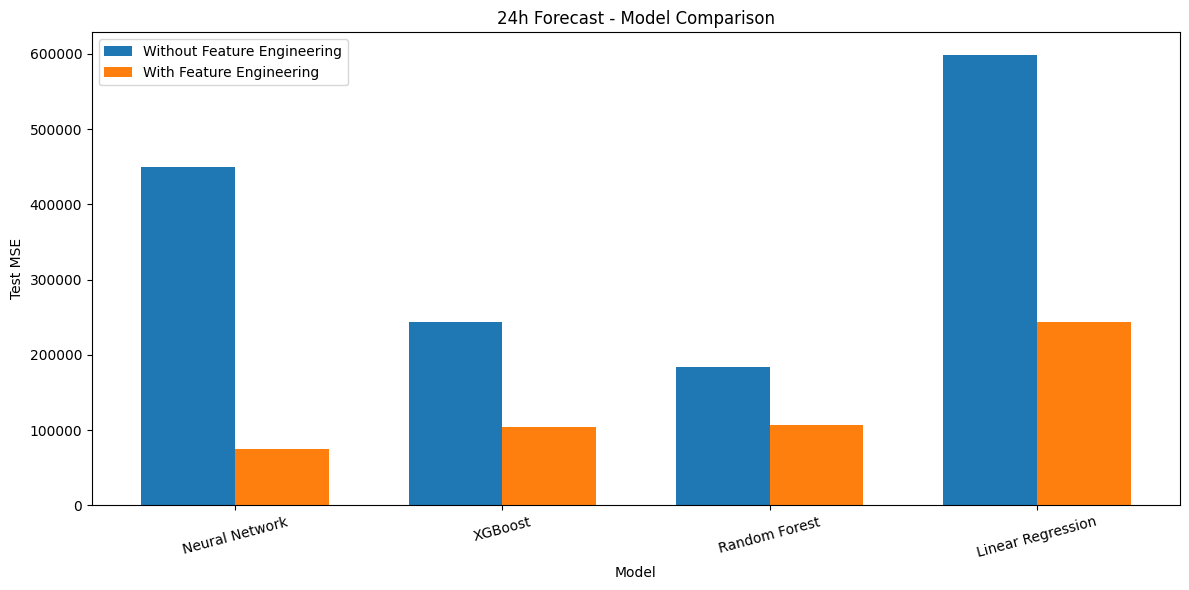

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Load results
# =====================================================

results_with_fe_1h = pd.read_csv(
    "results_with_feature_engineering_1h.csv"
)

results_without_fe_1h = pd.read_csv(
    "results_without_feature_engineering_1h.csv"
)

results_with_fe_24h = pd.read_csv(
    "results_with_feature_engineering_24h.csv"
)

results_without_fe_24h = pd.read_csv(
    "results_without_feature_engineering_24h.csv"
)

# =====================================================
# Function for plotting
# =====================================================

def plot_results(results_with_fe, results_without_fe, horizon):

    # Sort models consistently
    models = results_with_fe["Model"].tolist()

    mse_with_fe = (
        results_with_fe
        .set_index("Model")
        .loc[models]["Test MSE"]
        .values
    )

    mse_without_fe = (
        results_without_fe
        .set_index("Model")
        .loc[models]["Test MSE"]
        .values
    )

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(12, 6))

    plt.bar(
        x - width / 2,
        mse_without_fe,
        width,
        label="Without Feature Engineering"
    )

    plt.bar(
        x + width / 2,
        mse_with_fe,
        width,
        label="With Feature Engineering"
    )

    plt.xticks(x, models, rotation=15)

    plt.ylabel("Test MSE")
    plt.xlabel("Model")
    plt.title(f"{horizon} Forecast - Model Comparison")

    plt.legend()

    plt.tight_layout()
    plt.show()


# =====================================================
# 1h Plot
# =====================================================

plot_results(
    results_with_fe_1h,
    results_without_fe_1h,
    horizon="1h"
)

# =====================================================
# 24h Plot
# =====================================================

plot_results(
    results_with_fe_24h,
    results_without_fe_24h,
    horizon="24h"
)